In [2]:
!pip install google_play_scraper
!pip install textblob
import google_play_scraper
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8') # Updated to a supported seaborn style
plt.rcParams["figure.figsize"] = (15,10)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00


In [3]:
#Android App CIS PDAM Surabaya link from Google Play at
#https://play.google.com/store/apps/details?id=info.pdamsby.go.id.pdam
#The apps ID found in the link after id=uk.nhs.covid19.production
#The apps name on Google Play titled: NHS COVID-19 Department of Health and Social Care, UK Government
#Dated 17 April 2022: number of reviews 134,397

from google_play_scraper import app, Sort, reviews_all

cispdam_reviews = reviews_all(
    'info.pdamsby.go.id.pdam',
    sleep_milliseconds=0, # defaults to 0
    lang='en', # defaults to 'en'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [4]:
df_cispdamrev = pd.DataFrame(np.array(cispdam_reviews),columns=['content'])
df_cispdamrev = df_cispdamrev.join(pd.DataFrame(df_cispdamrev.pop('content').tolist()))
df_cispdamrev.to_csv(r'df_cispdamrev.csv', index=False)
df_cispdamrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e247ae20-d9e0-4dc0-9903-54af1569681f,Imelda Kristianti,https://play-lh.googleusercontent.com/a-/ALV-U...,"abis update malah ga muncul apa², dan terus²an...",1,0,6.10.0,2026-03-04 13:21:57,None,NaT,6.10.0
1,cb66d30d-d518-4463-a4ed-3d558d6fea4c,Boby Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Upload versi terbaru tidak bisa di buka???,1,0,6.10.0,2026-03-04 03:55:16,None,NaT,6.10.0
2,6f0c8d48-24db-461a-88ef-5a2811226961,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,untuk cek mandiri di bulan Maret ini tiba2 ngg...,3,2,6.10.0,2026-03-03 08:14:26,None,NaT,6.10.0
3,cd93882a-3425-46eb-995d-275106d1f2dc,ardyan novanto,https://play-lh.googleusercontent.com/a-/ALV-U...,setelah update terbaru dan info gangguan serve...,2,0,6.10.0,2026-02-26 08:12:32,None,NaT,6.10.0
4,05bb3a43-d1af-4f69-8157-ec1ae63c6c3e,Hendra Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,ini app kenapa tidak bisa login ya? dibuka han...,1,1,6.10.0,2026-02-26 02:21:40,None,NaT,6.10.0


In [5]:
print(df_cispdamrev.reviewCreatedVersion.unique())
print(df_cispdamrev.reviewCreatedVersion.nunique())

['6.10.0' None '6.4.5' '6.9.0' '6.8.0' '6.7.0' '6.6.0' '6.5.0' '6.4.3'
 '6.3.0' '5.6' '5.5' '6.2.0' '6.1.0' '6.0.0' '5.19' '5.18' '5.17' '5.16'
 '5.15' '5.14' '2.7' '5.13' '5.12' '5.11' '5.10' '5.9' '5.8' '5.0' '5.3'
 '5.4' '5.2' '3.7' '4.9' '4.5' '4.8' '4.6' '4.2' '4.4' '3.8' '4.0' '3.9'
 '3.5' '3.4' '3.3' '3.1' '2.8' '2.4' '2.3' '2.2' '2.0' '1.10' '1.8' '1.6'
 '1.4' '1.3' '1.1']
56


In [6]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_cispdamrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"abis update malah ga muncul apa², dan terus²an...",1,0,6.10.0,2026-03-04 13:21:57,None,NaT
1,Upload versi terbaru tidak bisa di buka???,1,0,6.10.0,2026-03-04 03:55:16,None,NaT
2,untuk cek mandiri di bulan Maret ini tiba2 ngg...,3,2,6.10.0,2026-03-03 08:14:26,None,NaT
3,setelah update terbaru dan info gangguan serve...,2,0,6.10.0,2026-02-26 08:12:32,None,NaT
4,ini app kenapa tidak bisa login ya? dibuka han...,1,1,6.10.0,2026-02-26 02:21:40,None,NaT
...,...,...,...,...,...,...,...
401,APLIKASI,5,0,1.4,2014-01-21 06:38:52,None,NaT
402,Josss sangat membantu,5,0,1.4,2014-01-16 15:12:20,None,NaT
403,Helpfull,3,0,1.4,2013-12-14 05:19:37,None,NaT
404,Aplikasinya sip!,5,0,1.3,2013-11-16 11:55:27,None,NaT


In [7]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.7 MB/s eta 0:00:00


In [8]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
df_cispdamrev['content'] = df_cispdamrev['content'].astype(str).fillna('')
df_cispdamrev['sentiment_polarity'] = df_cispdamrev['content'].apply(lambda x: TextBlob(x).polarity)
df_cispdamrev['sentiment_subjective'] = df_cispdamrev['content'].apply(lambda x: TextBlob(x).subjectivity)

In [9]:
#df_nhsrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]
df_cispdamrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,0.0
1,Upload versi terbaru tidak bisa di buka???,1,0.0,0.0
2,untuk cek mandiri di bulan Maret ini tiba2 ngga bs login pakai no HP OTP nya tidak terkirim meski dicoba beberapa kali.,3,0.0,0.0
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,0.0
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,0.0
...,...,...,...,...
401,APLIKASI,5,0.0,0.0
402,Josss sangat membantu,5,0.0,0.0
403,Helpfull,3,0.0,0.0
404,Aplikasinya sip!,5,0.0,0.0


In [10]:
#Check number of reviews scores
df_cispdamrev['score'].value_counts()

,count
score,
1,169
5,131
3,41
2,34
4,31


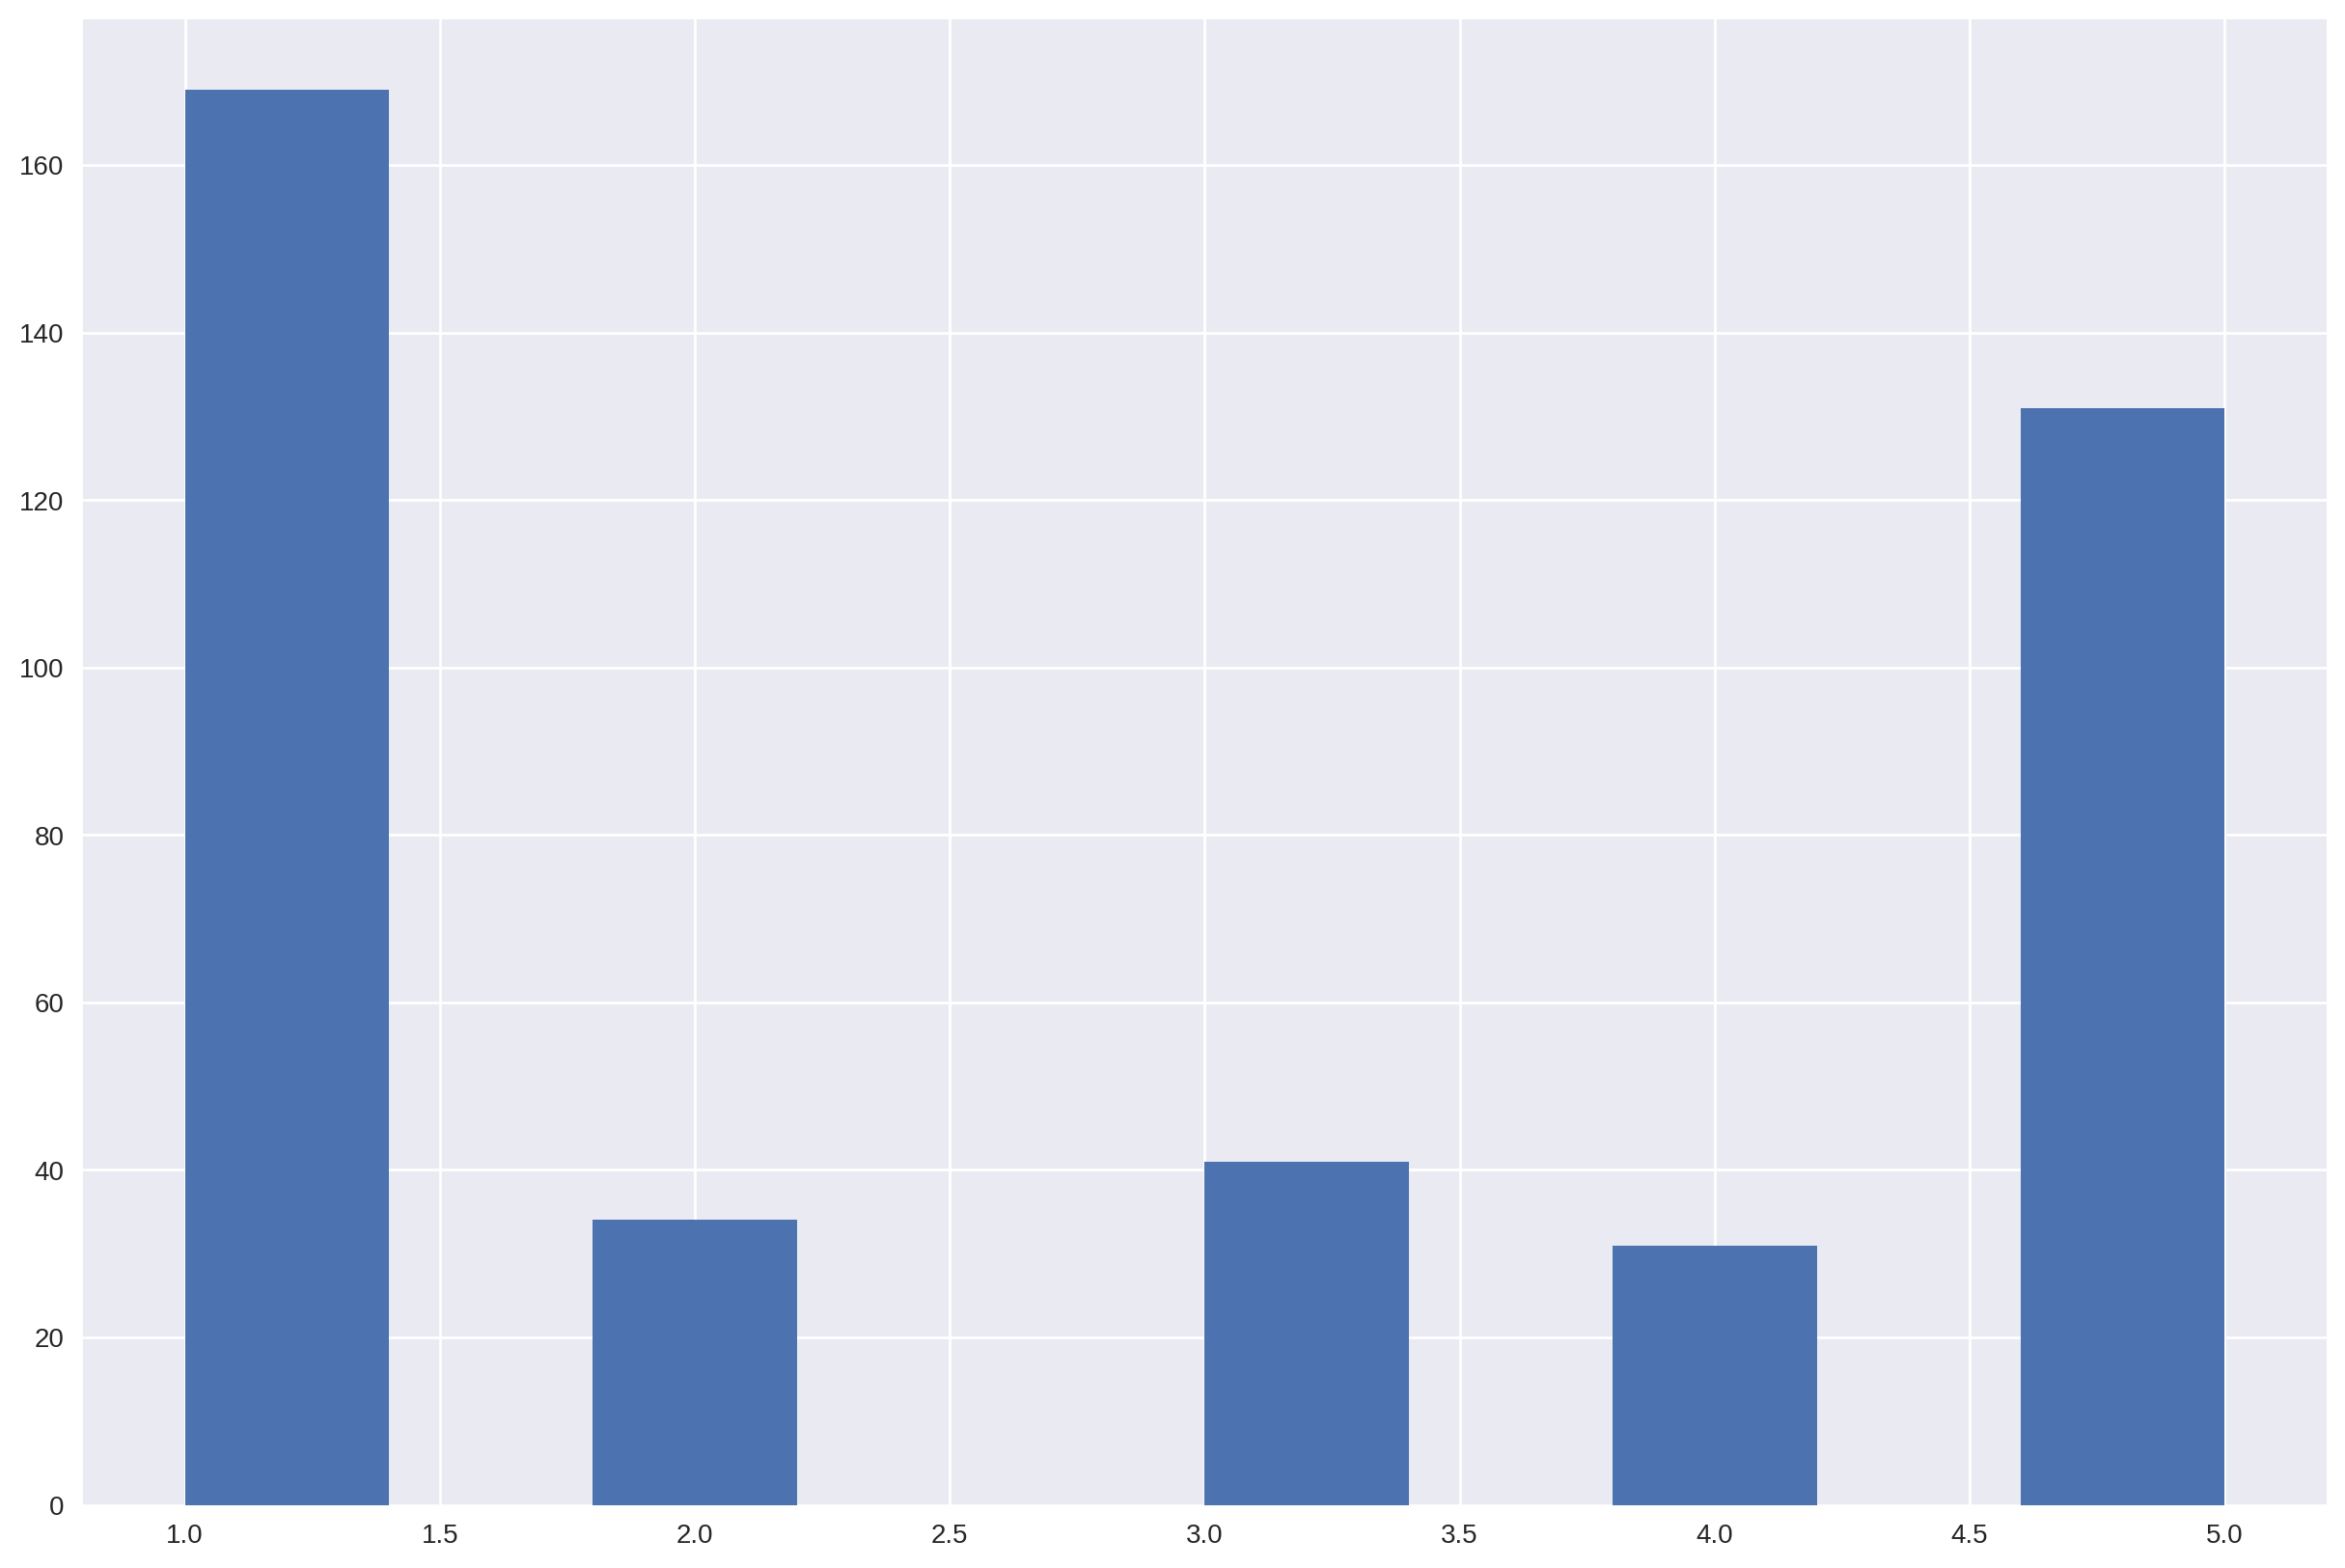

In [11]:
plt.hist(df_cispdamrev['score'])
plt.show()

# **Tokenization**

In [13]:
df_cispdamrev['content'] = df_cispdamrev['content'].astype(str)
print(df_cispdamrev['content'][0])

abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...


In [14]:
#Lowercase all reviews to see the difference
df_cispdamrev['content']= df_cispdamrev['content'].apply(lambda x: x.lower())
print(df_cispdamrev['content'][0])

abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...


In [15]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_cispdamrev['wordCount'] = [len(review.split()) for review in df_cispdamrev['content']]

df_cispdamrev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_cispdamrev['content']]

df_cispdamrev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_cispdamrev['content']]

In [20]:
df_cispdamrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,0.0,11,0,4
1,upload versi terbaru tidak bisa di buka???,1,0.0,0.0,7,0,3
2,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,3,0.0,0.0,22,0,1
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,0.0,19,0,2
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,0.0,14,0,1
...,...,...,...,...,...,...,...
401,aplikasi,5,0.0,0.0,1,0,0
402,josss sangat membantu,5,0.0,0.0,3,0,0
403,helpfull,3,0.0,0.0,1,0,0
404,aplikasinya sip!,5,0.0,0.0,2,0,1


In [17]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [18]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

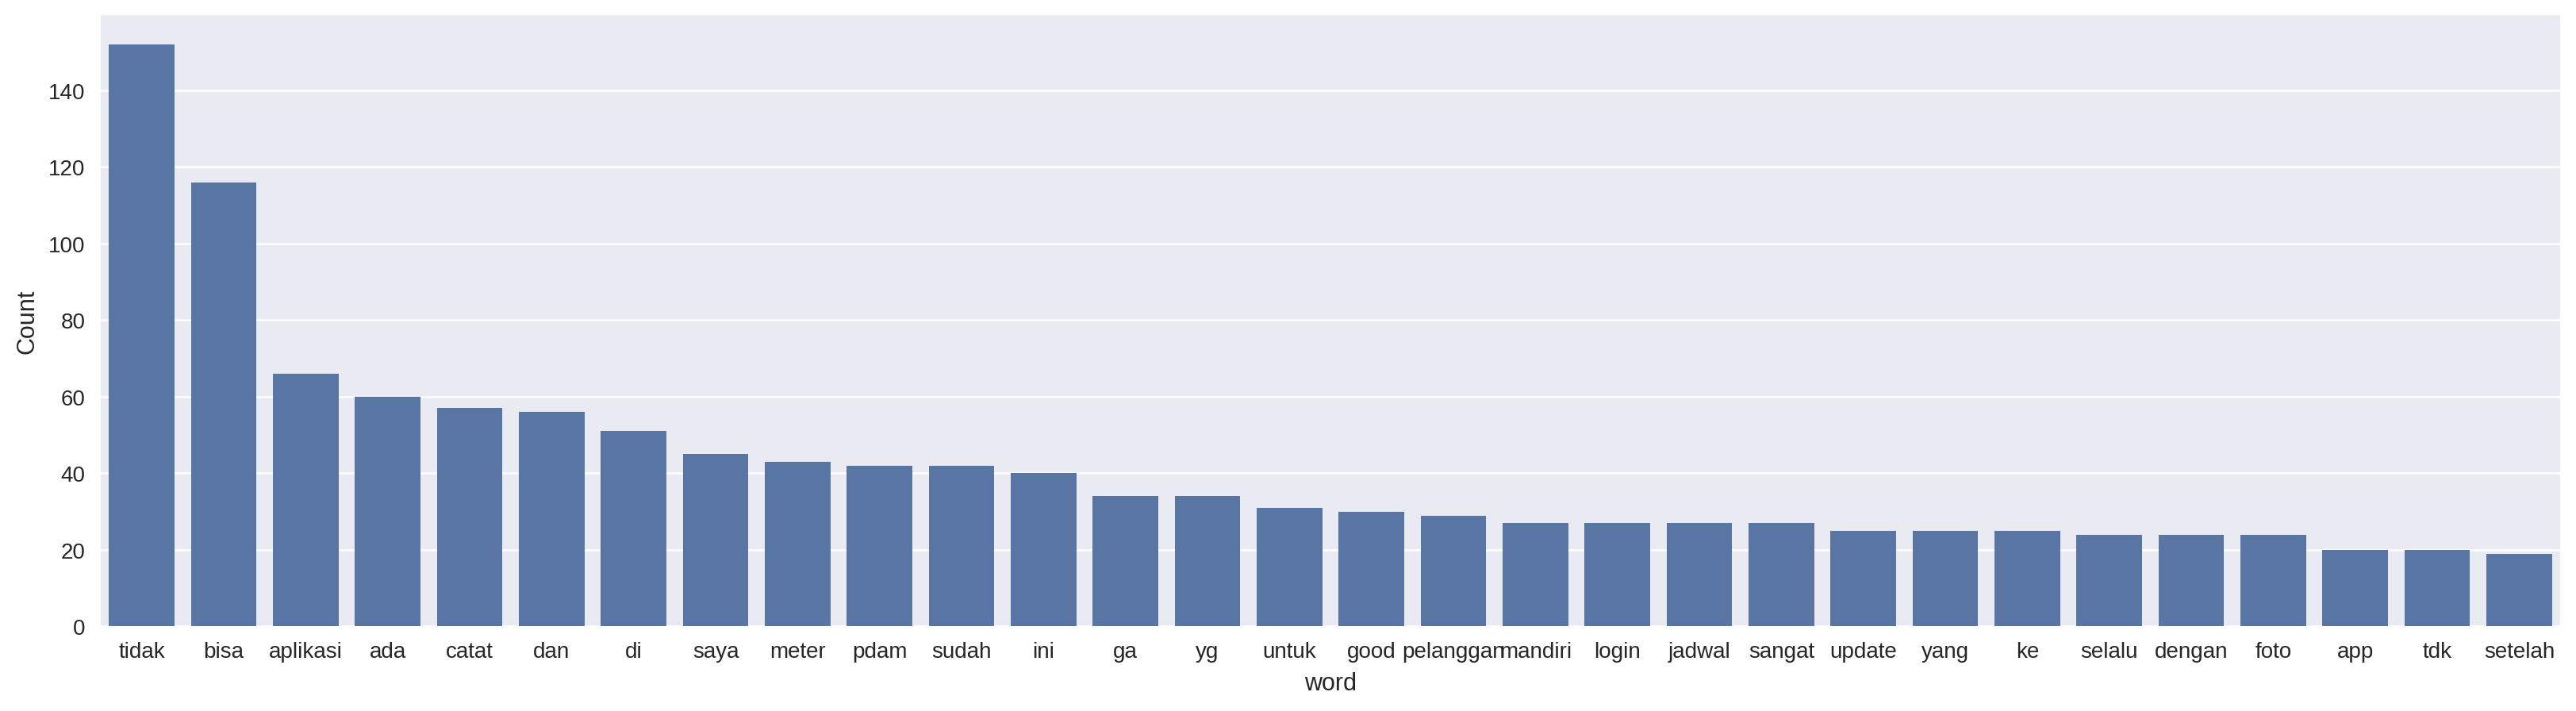

In [19]:
freq_words(df_cispdamrev['content'])

In [21]:
#check if there is any special character
alphabet = string.ascii_letters+string.punctuation
print(df_cispdamrev.content.str.strip(alphabet).astype(bool).any())

extracted_emojis=[]

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)

for y in df_cispdamrev['content']:
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis)

True
['[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🙏', '🙏', '🙏']", '[]', '[]', '[]', "['👍', '👍']", "['👍', '🏻']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😭', '😭', '😭', '😭', '😭']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🥰']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍', '🏼', '👍', '🏼']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🤢']", '[]', '[]', '[]', '[]', '[]', '[]

In [22]:
df_cispdamrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,0.0,11,0,4
1,upload versi terbaru tidak bisa di buka???,1,0.0,0.0,7,0,3
2,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,3,0.0,0.0,22,0,1
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,0.0,19,0,2
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,0.0,14,0,1
...,...,...,...,...,...,...,...
401,aplikasi,5,0.0,0.0,1,0,0
402,josss sangat membantu,5,0.0,0.0,3,0,0
403,helpfull,3,0.0,0.0,1,0,0
404,aplikasinya sip!,5,0.0,0.0,2,0,1


In [23]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_cispdamrev['sentiment_rating'] = df_cispdamrev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [24]:
df_cispdamrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,0.0,Negative
1,upload versi terbaru tidak bisa di buka???,1,0.0,0.0,Negative
2,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,3,0.0,0.0,Neutral
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,0.0,Negative
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,0.0,Negative
...,...,...,...,...,...
401,aplikasi,5,0.0,0.0,Positive
402,josss sangat membantu,5,0.0,0.0,Positive
403,helpfull,3,0.0,0.0,Neutral
404,aplikasinya sip!,5,0.0,0.0,Positive


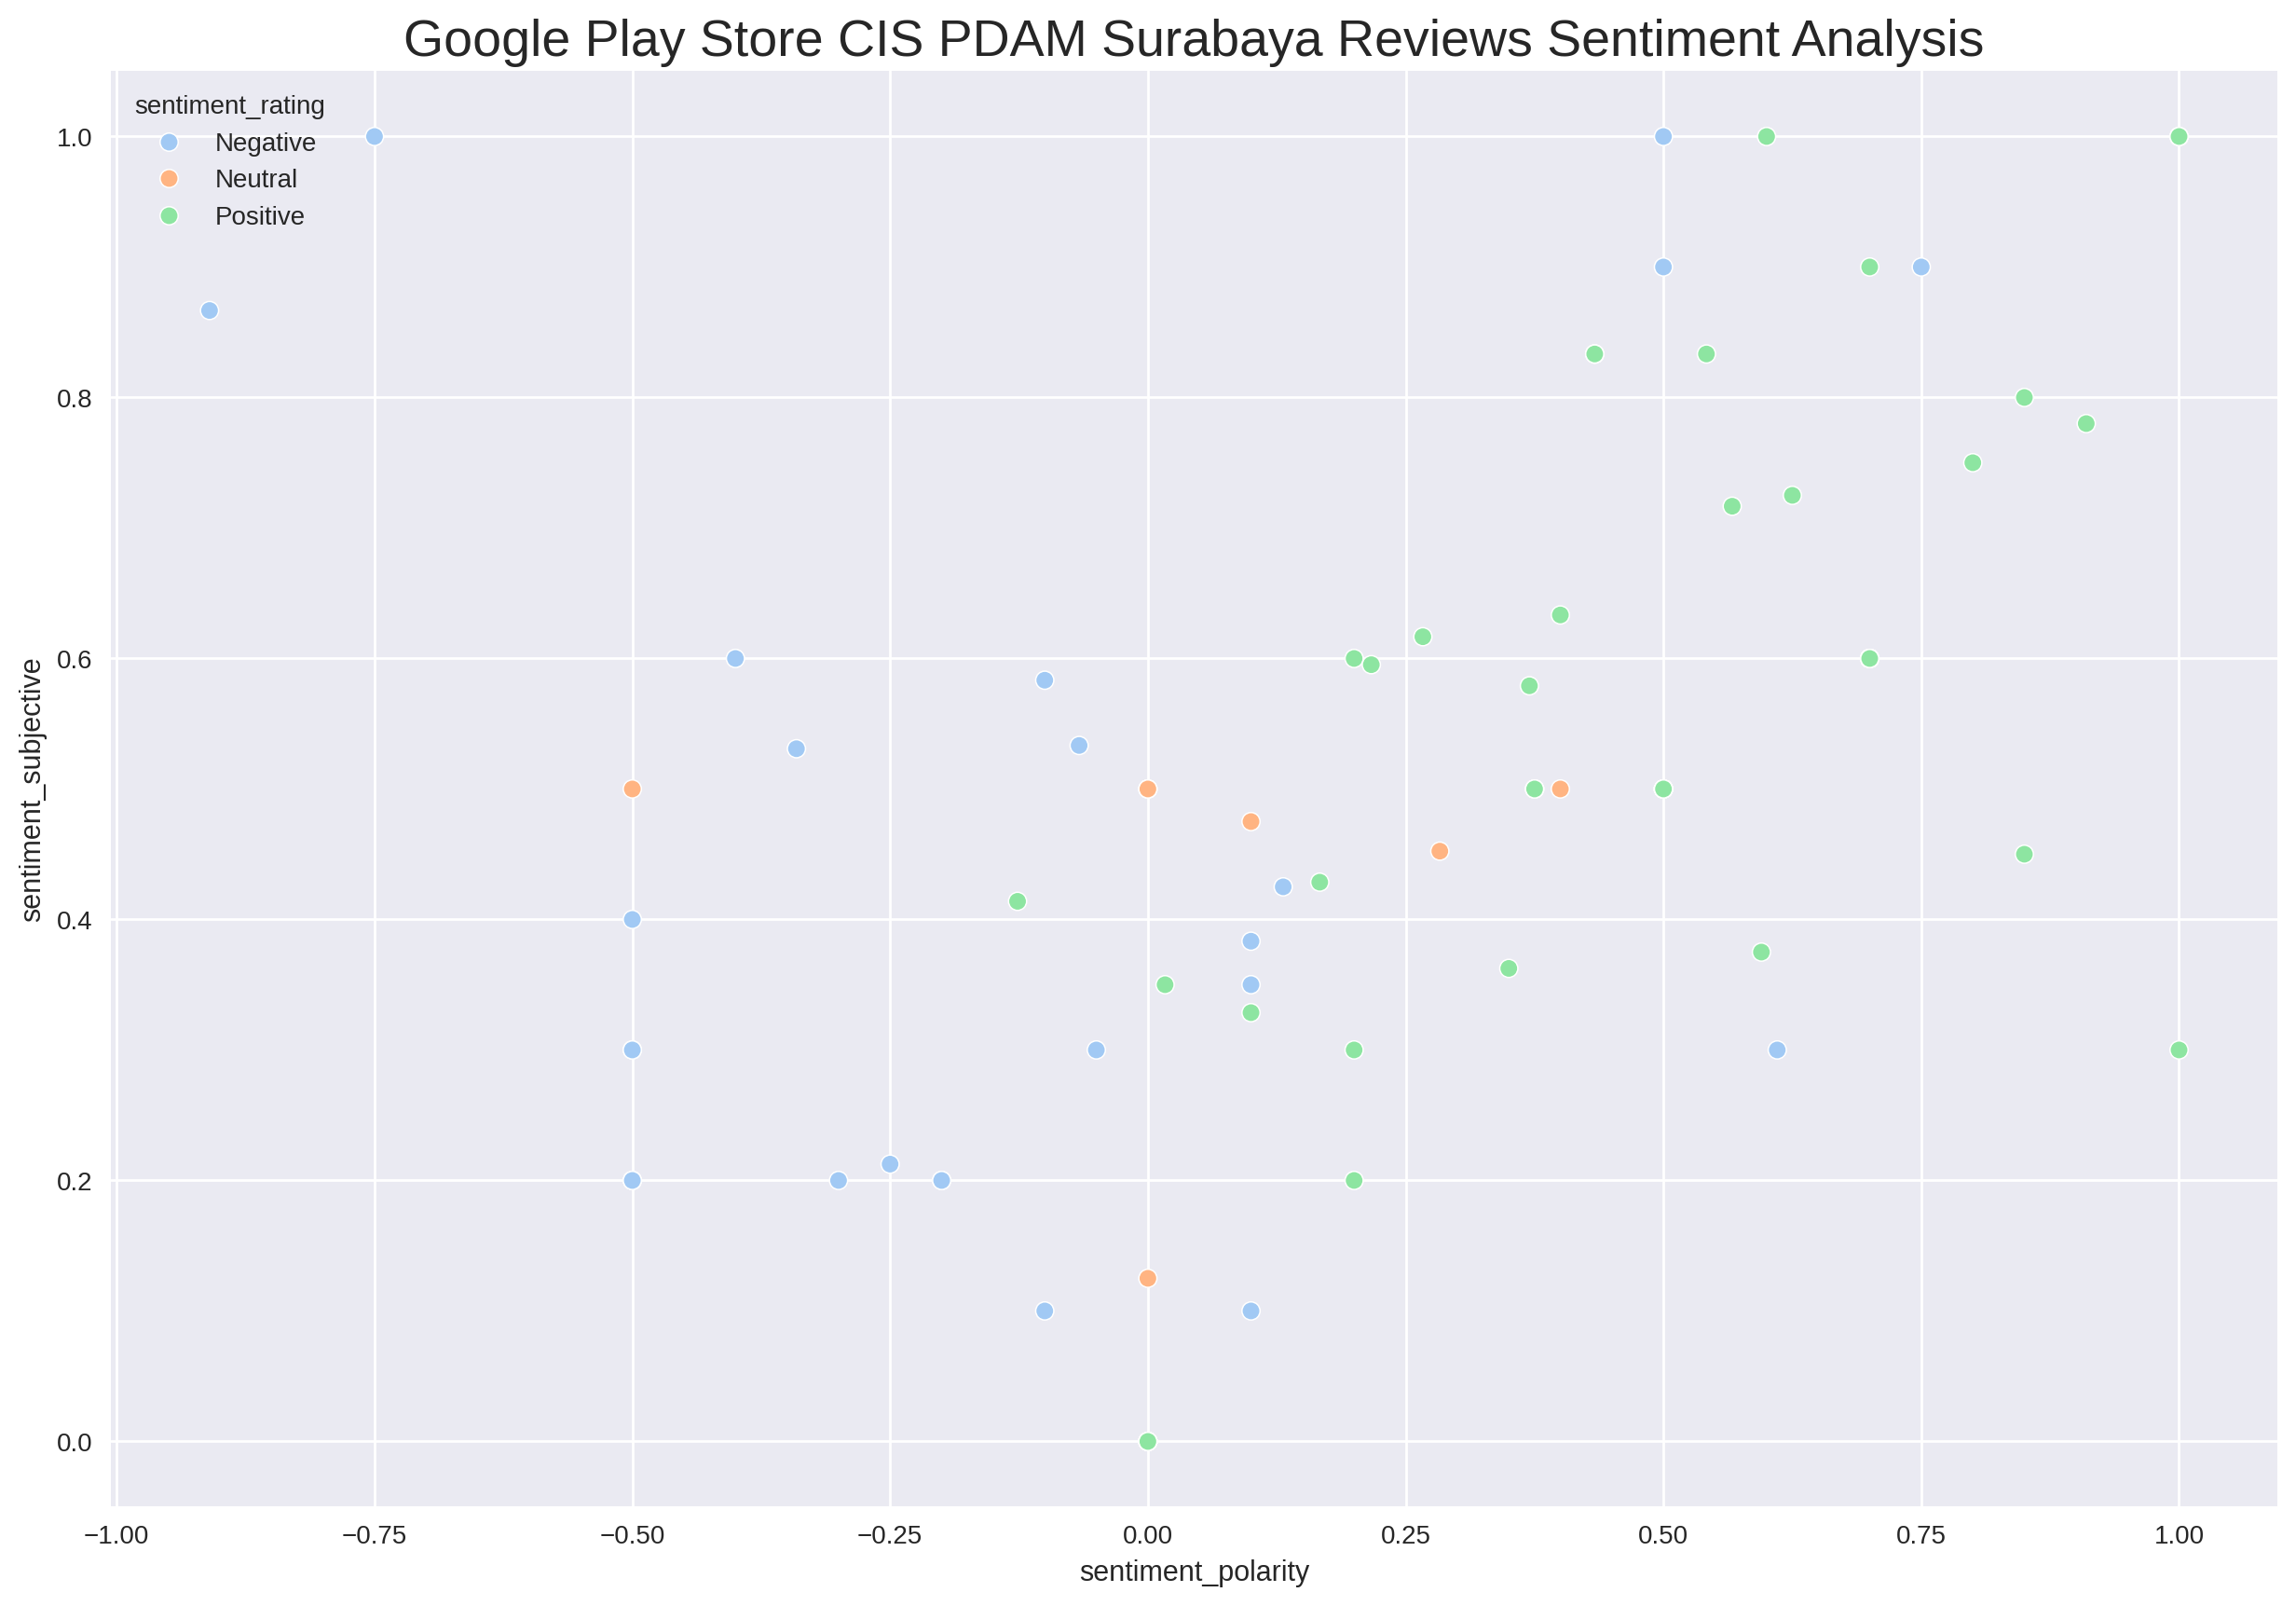

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_cispdamrev['sentiment_polarity'], y=df_cispdamrev['sentiment_subjective'],
                hue = df_cispdamrev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store CIS PDAM Surabaya Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [27]:
#Print the extracted emojis review column (content) before stopwords
df_cispdamrev.to_csv('df_cispdamrev_before_stopwords_sentiment_rating.csv', index = False)

In [28]:
import nltk
from nltk.corpus import stopwords
stop = stopwords.words('english') + ["someone","still","would","need"]
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [29]:
print(len(stop))

202


In [30]:
df_cispdamrev_stopwords = df_cispdamrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

In [31]:
# Exclude stopwords
df_cispdamrev_stopwords['tweet_without_stopwords'] = df_cispdamrev_stopwords['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
print(df_cispdamrev_stopwords)

                                                                                                                               content  \
0                                                             abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...   
1                                                                                           upload versi terbaru tidak bisa di buka???   
2              untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.   
3    setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak   
4                                               ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi   
..                                                                                                                                 ...   
401                               

In [32]:
pat = r'\b(?:{})\b'.format('|'.join(stop))
df_cispdamrev_stopwords['tweet_without_stopwords'] = df_cispdamrev_stopwords['content'].str.replace(pat, '')
df_cispdamrev_stopwords['tweet_without_stopwords'] = df_cispdamrev_stopwords['tweet_without_stopwords'].str.replace(r'\s+', ' ')

In [33]:
#Save into csv after applying stopwords
df_cispdamrev_stopwords.to_csv('df_cispdamrev_after_stopwords_sentiment_rating2.csv', index = False)

In [34]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_cispdamrev_stopwords['wordCount'] = [len(review.split()) for review in df_cispdamrev_stopwords['content']]
df_cispdamrev_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_cispdamrev_stopwords['tweet_without_stopwords']]

In [35]:
df_cispdamrev_stopwords.loc[:,["content","score","sentiment_polarity", "sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_polarity,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,0.0,Negative,11,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",11
1,upload versi terbaru tidak bisa di buka???,1,0.0,Negative,7,upload versi terbaru tidak bisa di buka???,7
2,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,3,0.0,Neutral,22,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,22
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,0.0,Negative,19,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",19
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,0.0,Negative,14,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,14
...,...,...,...,...,...,...,...
401,aplikasi,5,0.0,Positive,1,aplikasi,1
402,josss sangat membantu,5,0.0,Positive,3,josss sangat membantu,3
403,helpfull,3,0.0,Neutral,1,helpfull,1
404,aplikasinya sip!,5,0.0,Positive,2,aplikasinya sip!,2


In [36]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

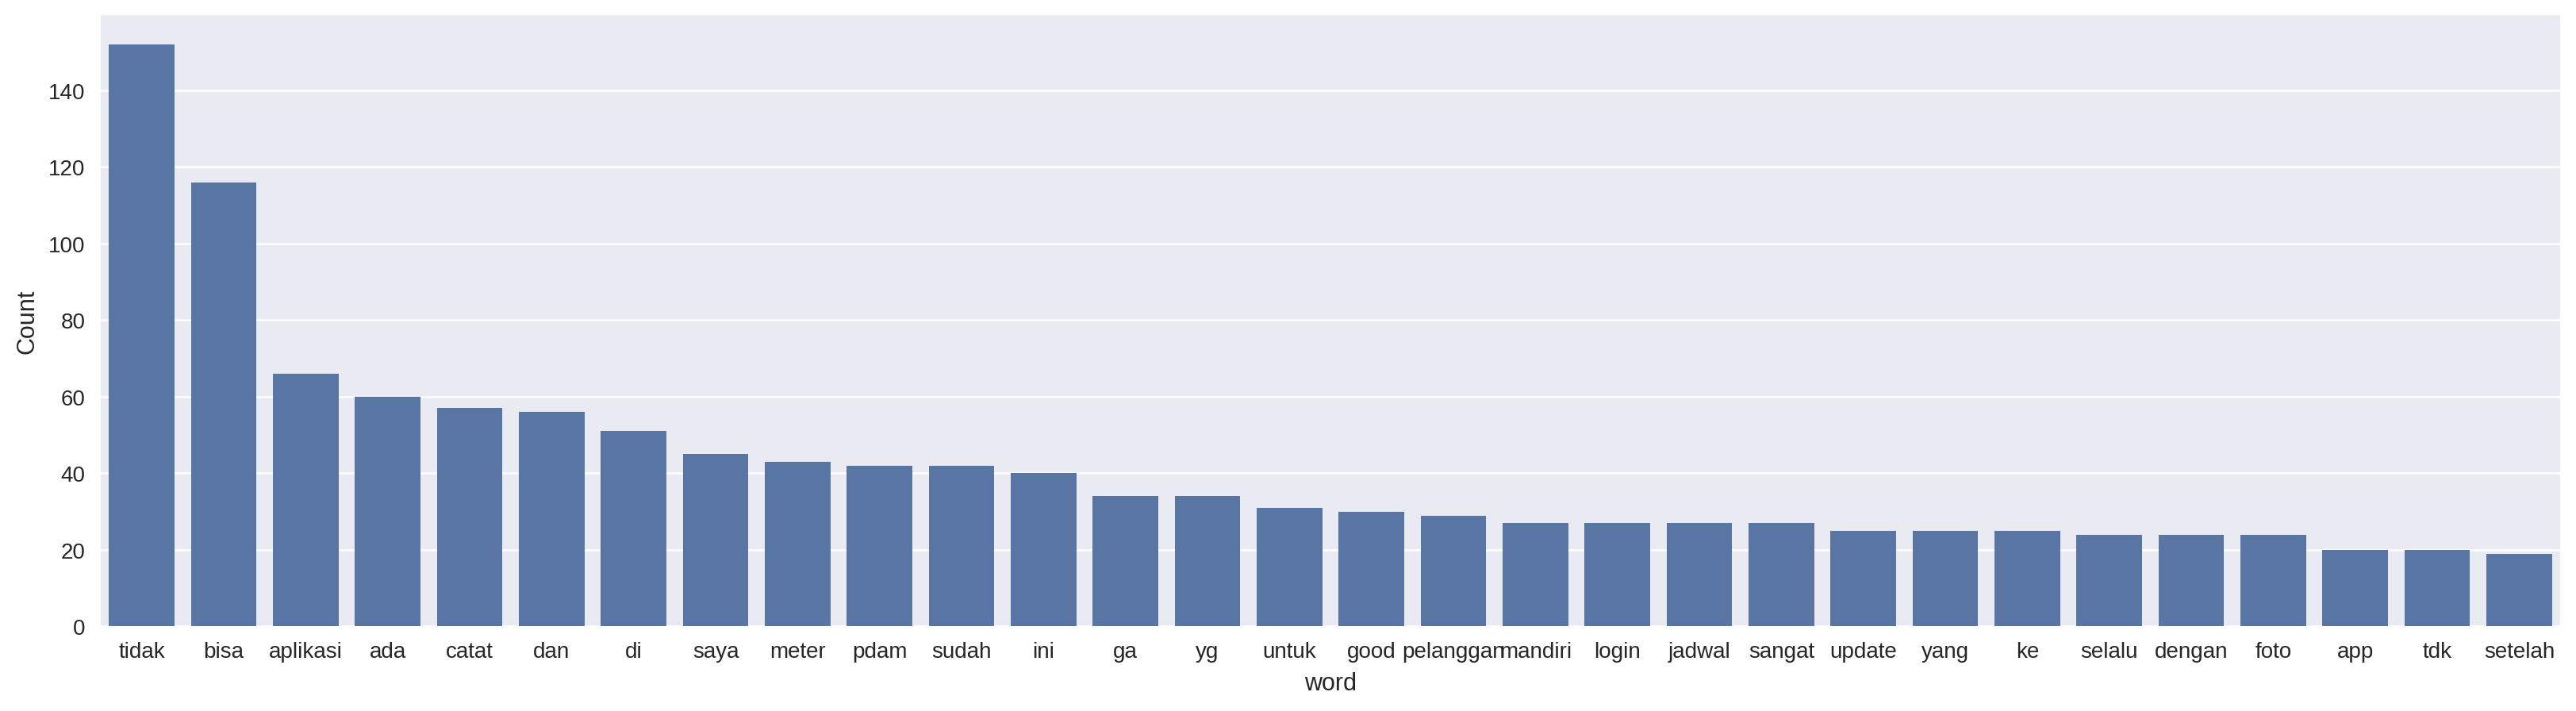

In [37]:
freq_words(df_cispdamrev_stopwords['tweet_without_stopwords'])

In [38]:
newStopWords = ["'",".",",", "someone","still","would","need"]

#from nltk.corpus import stopwords
#stoplist = stopwords.words('english') + ['though']

#NOT YET DONE ==== 24 May 2022

In [39]:
#Stemming

#Stemming function chops off the end of the word
#and transform the word into its root form.
#All suffixes like -s, -es, -ed, -ing are removed.

def stemming(x):
    st = PorterStemmer()
    if x is not None:
       for word in x.split():
           st.stem(word)

df_cispdamrev_stopwords['tweet_without_stopwords'].apply(lambda x:stemming(x))
print(df_cispdamrev_stopwords['tweet_without_stopwords'][0])

abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...


In [40]:
#===BIGRAM https://towardsdatascience.com/text-analysis-basics-in-python-443282942ec5 not yet
#Creating bigram/trigram to search

In [41]:
#DROP NA
df_cispdamrev_stopwords.dropna(inplace=True)
df_cispdamrev_stopwords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    406 non-null    object 
 1   score                      406 non-null    int64  
 2   sentiment_polarity         406 non-null    float64
 3   sentiment_subjective       406 non-null    float64
 4   sentiment_rating           406 non-null    object 
 5   tweet_without_stopwords    406 non-null    object 
 6   wordCount                  406 non-null    int64  
 7   wordCount_after_stopwords  406 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 25.5+ KB


In [42]:
df_cispdamrev_stopwords.loc[:,["content","score","sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",1,Negative,11,"abis update malah ga muncul apa², dan terus²an memeriksa koneksi anda...",11
1,upload versi terbaru tidak bisa di buka???,1,Negative,7,upload versi terbaru tidak bisa di buka???,7
2,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,3,Neutral,22,untuk cek mandiri di bulan maret ini tiba2 ngga bs login pakai no hp otp nya tidak terkirim meski dicoba beberapa kali.,22
3,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",2,Negative,19,"setelah update terbaru dan info gangguan server, sampai sekarang tidak stabil. cek history tagihan aja kadang tampil kadang tidak",19
4,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,1,Negative,14,ini app kenapa tidak bisa login ya? dibuka hanya muter2 saja tulisan memeriksa koneksi,14
...,...,...,...,...,...,...
401,aplikasi,5,Positive,1,aplikasi,1
402,josss sangat membantu,5,Positive,3,josss sangat membantu,3
403,helpfull,3,Neutral,1,helpfull,1
404,aplikasinya sip!,5,Positive,2,aplikasinya sip!,2
